# Manufacturing Defect Prediction — SECOM Sensor Data

Dataset: [UCI SECOM](https://archive.ics.uci.edu/dataset/179/secom) — 1,567 production runs from a real semiconductor fab, 590 sensor readings each, pass/fail outcome.

Goal: catch failing units from sensor data before they ship. Only 6.6% of units actually fail, so this is a real imbalanced classification problem, not a toy dataset.

Rough structure below: EDA, then cleaning (590 sensors down to ~195), then three models, then a threshold analysis that ended up being the actual interesting part.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score,
                              f1_score, recall_score, precision_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

data = pd.read_csv('data/secom.data', sep=' ', header=None)
labels = pd.read_csv('data/secom_labels.data', sep=' ', header=None, names=['label', 'timestamp'])

data.columns = [f'sensor_{i}' for i in range(data.shape[1])]
labels['timestamp'] = labels['timestamp'].str.strip('"')
labels['timestamp'] = pd.to_datetime(labels['timestamp'], format='%d/%m/%Y %H:%M:%S')
labels['fail'] = (labels['label'] == 1).astype(int)

print(f"Data shape: {data.shape}")
print(f"Fail rate: {labels['fail'].mean()*100:.2f}% ({labels['fail'].sum()} fails / {len(labels)} total)")

Data shape: (1567, 590)
Fail rate: 6.64% (104 fails / 1567 total)


## 1. EDA


### Class balance

6.6% fail rate. Worth saying up front — accuracy is a useless metric here. A model that always predicts "pass" is already 93% "accurate" and catches zero real defects.


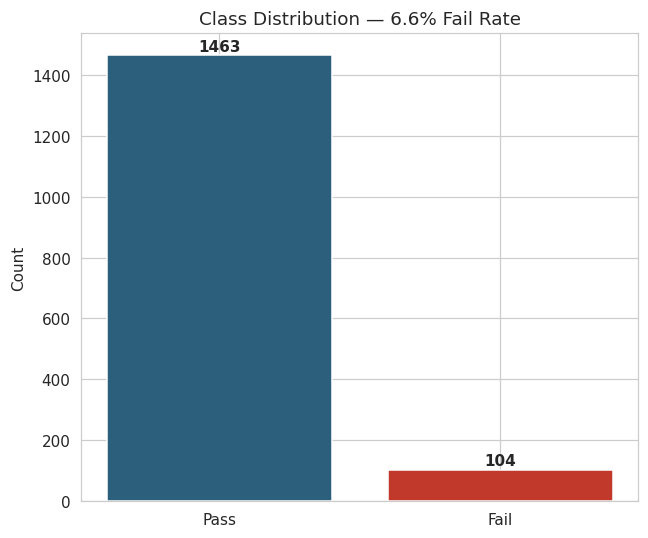

In [1]:
plt.figure(figsize=(6, 5))
counts = labels['fail'].value_counts().sort_index()
colors = ['#2C5F7C', '#C0392B']
bars = plt.bar(['Pass', 'Fail'], counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 15, str(val), ha='center', fontweight='bold')
plt.title(f'Class Distribution — {labels["fail"].mean()*100:.1f}% Fail Rate')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Missing data

590 sensors, so some are bound to drop out or misfire. Checking the spread before deciding what to drop vs. impute.


Columns with missing data: 538 / 590
Columns >50% missing: 28


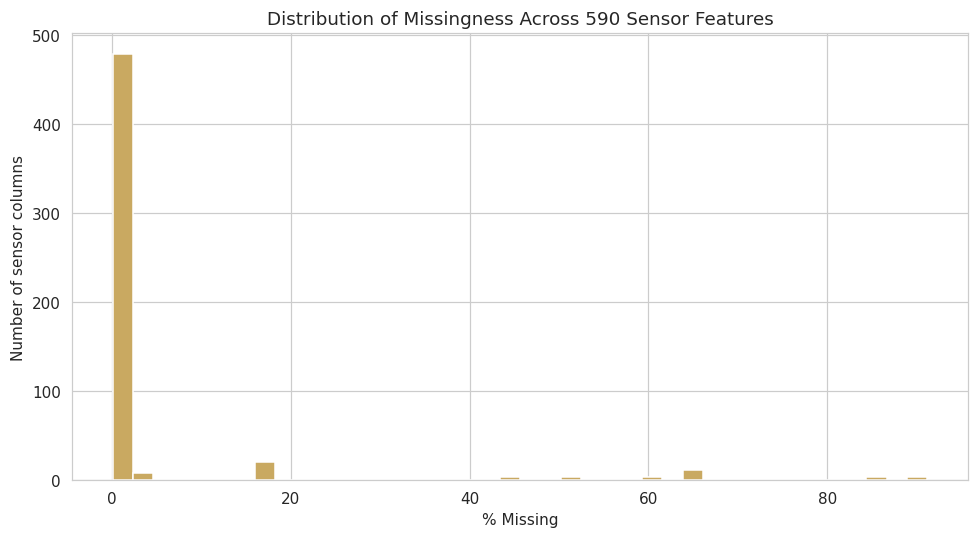

In [1]:
missing_pct = (data.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"Columns with missing data: {len(missing_pct)} / {data.shape[1]}")
print(f"Columns >50% missing: {(missing_pct > 50).sum()}")

plt.figure(figsize=(9, 5))
plt.hist(missing_pct, bins=40, color='#C9A961', edgecolor='white')
plt.xlabel('% Missing')
plt.ylabel('Number of sensor columns')
plt.title('Distribution of Missingness Across 590 Sensor Features')
plt.tight_layout()
plt.show()

### Does the fail rate drift over time?

Checking in case there's a process shift somewhere in the collection window rather than random noise.


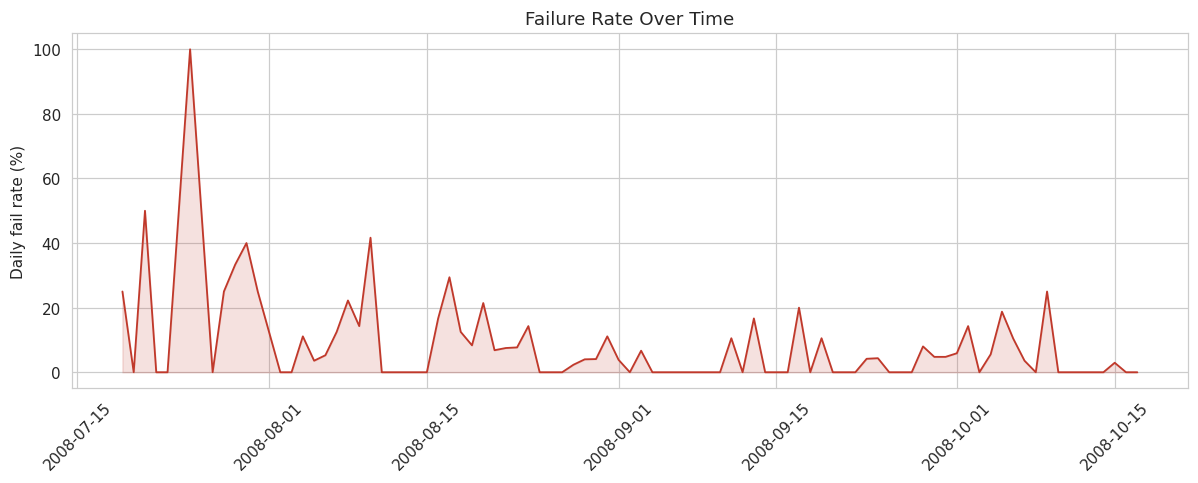

In [1]:
labels_sorted = labels.sort_values('timestamp')
labels_sorted['date'] = labels_sorted['timestamp'].dt.date
daily = labels_sorted.groupby('date')['fail'].agg(['sum', 'count'])
daily['fail_rate'] = daily['sum'] / daily['count']

plt.figure(figsize=(11, 4.5))
plt.plot(daily.index, daily['fail_rate'] * 100, color='#C0392B', linewidth=1.2)
plt.fill_between(daily.index, daily['fail_rate'] * 100, alpha=0.15, color='#C0392B')
plt.ylabel('Daily fail rate (%)')
plt.title('Failure Rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Noisy day to day but no single obvious jump — daily counts are small so some of this is just sampling noise. Treating it as per-unit prediction rather than looking for a specific time-based shift.


## 2. Cleaning

590 raw columns is a lot, and most of the actual work here is figuring out what to trust before modeling anything.

Three passes:
- drop anything >50% missing (too sparse to impute reasonably)
- drop near-zero-variance columns — a sensor that barely moves isn't giving you anything, probably dead or disconnected
- drop anything >0.95 correlated with something else already kept — redundant sensors just add noise


In [1]:
# Drop columns >50% missing
drop_cols = missing_pct[missing_pct > 50].index.tolist()
data_clean = data.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} columns >50% missing")

# Drop near-zero variance columns
variances_clean = data_clean.var(numeric_only=True)
nzv_cols = variances_clean[variances_clean < 0.01].index.tolist()
data_clean = data_clean.drop(columns=nzv_cols)
print(f"Dropped {len(nzv_cols)} near-zero-variance columns")
print(f"Remaining after steps 1-2: {data_clean.shape[1]}")

# Impute remaining missing values with the median (robust to sensor outliers)
imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(imputer.fit_transform(data_clean), columns=data_clean.columns)

# Drop highly correlated (redundant) sensors
corr_matrix = data_imputed.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
data_final = data_imputed.drop(columns=high_corr_cols)
print(f"Dropped {len(high_corr_cols)} highly correlated (redundant) sensor columns")
print(f"Final feature count: {data_final.shape[1]}")

y = labels['fail'].values
X = data_final

Dropped 28 columns >50% missing
Dropped 265 near-zero-variance columns
Remaining after steps 1-2: 297
Dropped 102 highly correlated (redundant) sensor columns
Final feature count: 195


## 3. Modeling

Stratified split so both sides keep roughly the same fail rate — with only 104 failures total an unlucky split could badly skew the test set.

Used `class_weight='balanced'` instead of SMOTE for the imbalance — didn't have imblearn available, and honestly class weighting is simpler to explain anyway.


In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape[0]} rows ({y_train.sum()} fails)")
print(f"Test set: {X_test.shape[0]} rows ({y_test.sum()} fails)")

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

results = []
roc_data = {}
pr_data = {}
fitted_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    fitted_models[name] = model
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_prec = average_precision_score(y_test, y_prob)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_data[name] = (prec_curve, rec_curve, avg_prec)

    results.append({
        'Model': name, 'ROC-AUC': round(roc_auc, 4), 'Avg Precision (PR-AUC)': round(avg_prec, 4),
        'Recall (catch defects)': round(recall, 4), 'Precision': round(precision, 4), 'F1': round(f1, 4)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

Train set: 1175 rows (78 fails)
Test set: 392 rows (26 fails)


                 Model  ROC-AUC  ...  Precision      F1
0        Random Forest   0.8346  ...     0.0000  0.0000
1    Gradient Boosting   0.7871  ...     0.2222  0.1143
2  Logistic Regression   0.7094  ...     0.1667  0.2326

[3 rows x 6 columns]

### ROC and precision-recall

ROC-AUC first, but with 6.6% positives it can look better than it deserves to. Precision-recall is the more honest read — how many flagged units are actually bad (precision), against how many real defects you're catching (recall).


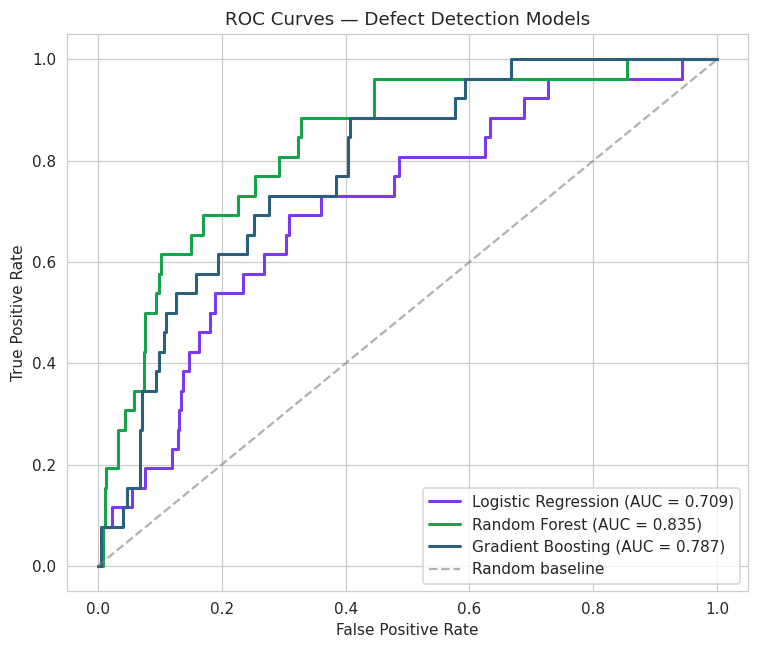

In [1]:
plt.figure(figsize=(7, 6))
colors_map = {'Logistic Regression': '#7C3AED', 'Random Forest': '#16A34A', 'Gradient Boosting': '#2C5F7C'}
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colors_map[name], linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', alpha=0.6, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Defect Detection Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

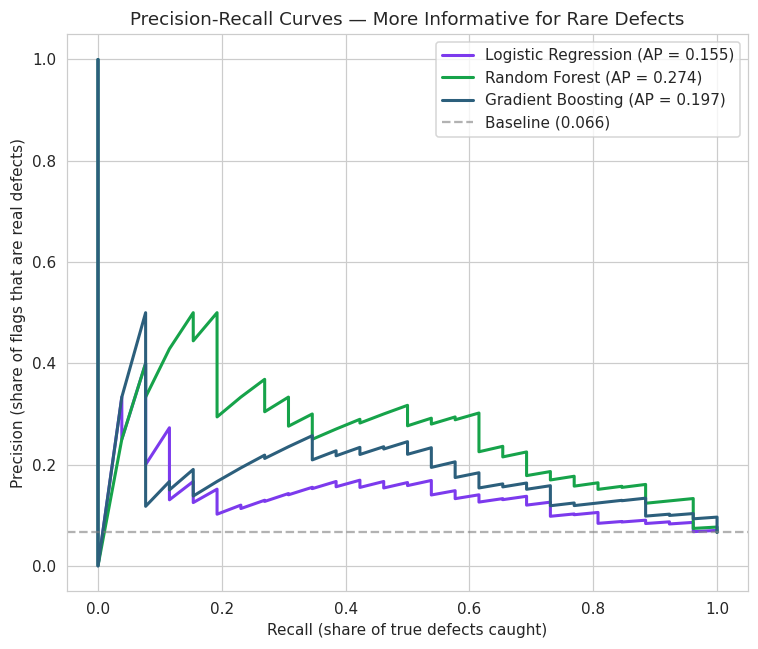

In [1]:
plt.figure(figsize=(7, 6))
for name, (prec, rec, ap) in pr_data.items():
    plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})', color=colors_map[name], linewidth=2)
baseline = y_test.mean()
plt.axhline(baseline, linestyle='--', color='grey', alpha=0.6, label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall (share of true defects caught)')
plt.ylabel('Precision (share of flags that are real defects)')
plt.title('Precision-Recall Curves — More Informative for Rare Defects')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Random Forest wins on ROC-AUC (0.835) but at the default 0.5 cutoff it predicts **zero** failures. Not a bug — with this little of the positive class, predicted probabilities for real failures just don't cross 0.5 on average.

This is kind of the actual point of the project: picking a good model and picking a good threshold are two separate problems. Good AUC doesn't mean 0.5 is usable. Threshold needs to be chosen deliberately — see the cost analysis below.


### Confusion matrix, best model


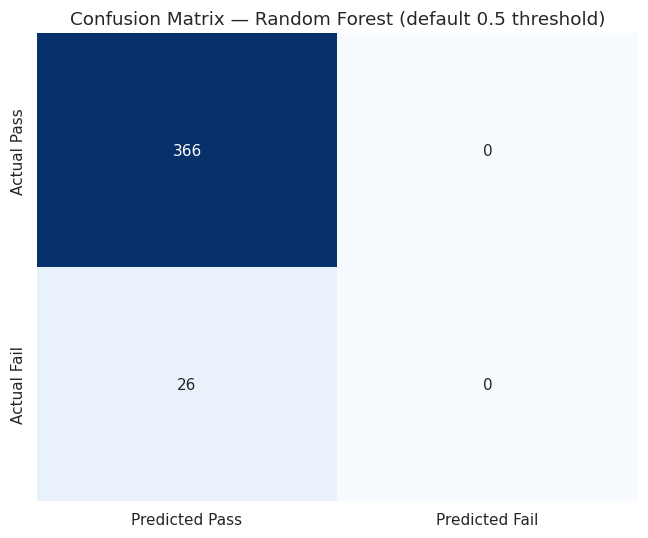

In [1]:
best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]
if best_name == 'Logistic Regression':
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title(f'Confusion Matrix — {best_name} (default 0.5 threshold)')
plt.tight_layout()
plt.show()

## 4. Feature importance

Which sensors is the model actually leaning on?


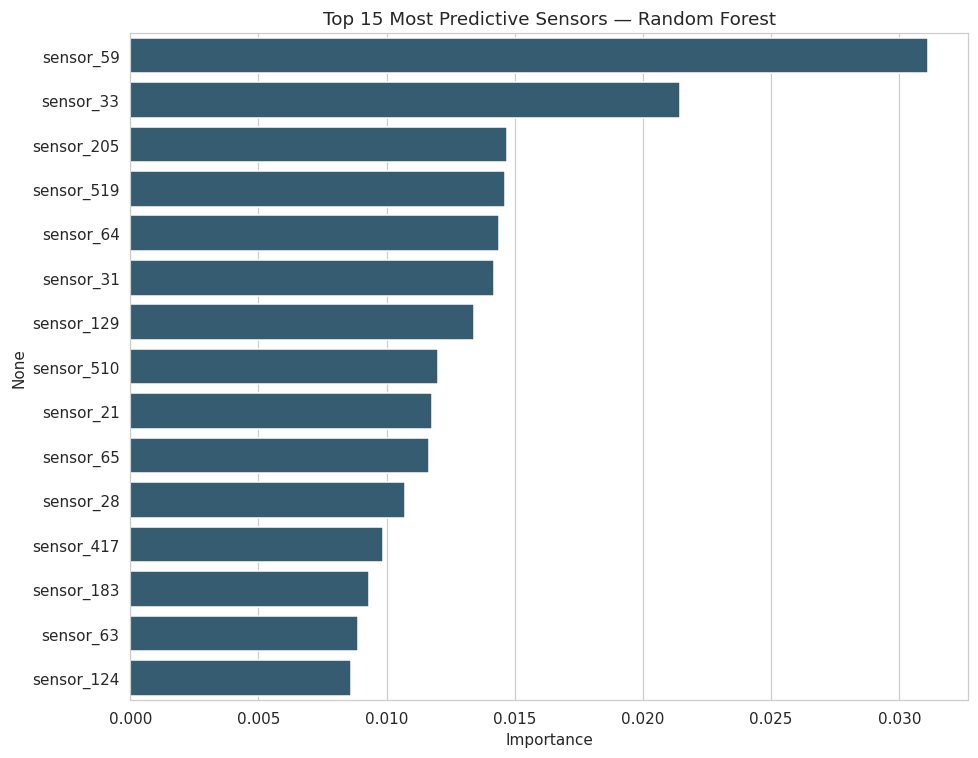

sensor_59     0.031125
sensor_33     0.021439
sensor_205    0.014710
sensor_519    0.014621
sensor_64     0.014378
sensor_31     0.014194
sensor_129    0.013411
sensor_510    0.011986
sensor_21     0.011787
sensor_65     0.011643
dtype: float64

In [1]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
elif best_name == 'Logistic Regression':
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, color='#2C5F7C')
plt.title(f'Top 15 Most Predictive Sensors — {best_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(10)

## 5. What threshold actually makes sense?

In a real fab, missing a bad unit (it ships, fails downstream) is a lot more expensive than flagging a good one for a second look. Assuming roughly a 50:1 cost ratio (rough number, but the direction is right) and solving for the threshold that minimizes total cost instead of defaulting to 0.5.


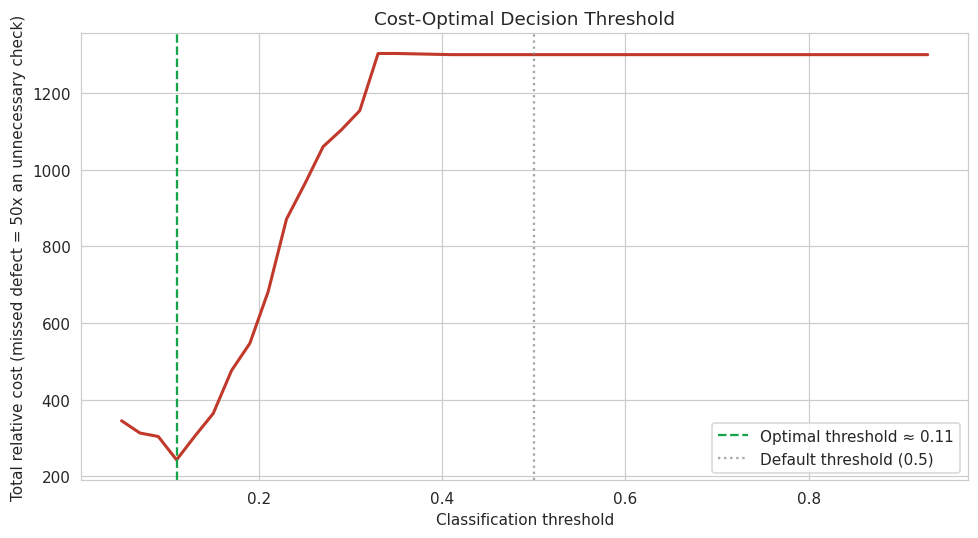

Default (0.5)   — Recall: 0.000, Precision: 0.000
Cost-optimal (0.11) — Recall: 0.962, Precision: 0.115


In [1]:
if best_name == 'Logistic Regression':
    y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_prob_best = best_model.predict_proba(X_test)[:, 1]

cost_fn = 50   # relative cost of a missed defect (ships to customer)
cost_fp = 1    # relative cost of an unnecessary inspection

thresholds = np.arange(0.05, 0.95, 0.02)
total_costs = []
for t in thresholds:
    preds = (y_prob_best >= t).astype(int)
    fn = ((preds == 0) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    total_costs.append(fn * cost_fn + fp * cost_fp)

optimal_idx = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, total_costs, color='#C0392B', linewidth=2)
plt.axvline(optimal_threshold, linestyle='--', color='#16A34A', label=f'Optimal threshold \u2248 {optimal_threshold:.2f}')
plt.axvline(0.5, linestyle=':', color='grey', alpha=0.7, label='Default threshold (0.5)')
plt.xlabel('Classification threshold')
plt.ylabel(f'Total relative cost (missed defect = {cost_fn}x an unnecessary check)')
plt.title('Cost-Optimal Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

default_preds = (y_prob_best >= 0.5).astype(int)
optimal_preds = (y_prob_best >= optimal_threshold).astype(int)
print(f"Default (0.5)   — Recall: {recall_score(y_test, default_preds):.3f}, Precision: {precision_score(y_test, default_preds, zero_division=0):.3f}")
print(f"Cost-optimal ({optimal_threshold:.2f}) — Recall: {recall_score(y_test, optimal_preds):.3f}, Precision: {precision_score(y_test, optimal_preds, zero_division=0):.3f}")

## Takeaways

- Imbalance was the real problem, not model choice — all three models found *some* signal, none were usable out of the box.
- Moving the threshold from 0.5 to ~0.11 took Random Forest from 0% recall to ~96% — at the cost of a lot more false alarms, which is the actual trade-off, not a downside to explain away.
- More than half of the original 590 sensors got dropped before modeling even started — cleaning mattered as much as the modeling itself.
- Accuracy would've been a misleading metric here; PR curves were more honest than ROC given how rare the positive class is.
- If I revisit this: try real SMOTE instead of class weighting for comparison, tune thresholds per-model instead of one shared analysis, and ideally get someone who actually knows the fab process to check whether the top sensors make physical sense.
